# APPENDIX
### PYTHON IMPLEMENTATION

## Room Occupancy Estimation using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


### 1. Load Dataset

In [3]:
df = pd.read_csv("Occupancy_Estimation.csv")
 
print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (10129, 19)


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


### 2. Basic Data Inspection

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())
 
print("\nDuplicate Rows:", df.duplicated().sum())
 
print("\nData Types:")
print(df.dtypes)
 
# Remove exact duplicate rows, if any
df = df.drop_duplicates().reset_index(drop=True)



Missing Values:
Date                    0
Time                    0
S1_Temp                 0
S2_Temp                 0
S3_Temp                 0
S4_Temp                 0
S1_Light                0
S2_Light                0
S3_Light                0
S4_Light                0
S1_Sound                0
S2_Sound                0
S3_Sound                0
S4_Sound                0
S5_CO2                  0
S5_CO2_Slope            0
S6_PIR                  0
S7_PIR                  0
Room_Occupancy_Count    0
dtype: int64

Duplicate Rows: 0

Data Types:
Date                     object
Time                     object
S1_Temp                 float64
S2_Temp                 float64
S3_Temp                 float64
S4_Temp                 float64
S1_Light                  int64
S2_Light                  int64
S3_Light                  int64
S4_Light                  int64
S1_Sound                float64
S2_Sound                float64
S3_Sound                float64
S4_Sound                floa

### 3. Target Distribution


Target Distribution:
Room_Occupancy_Count
0    8228
1     459
2     748
3     694
Name: count, dtype: int64


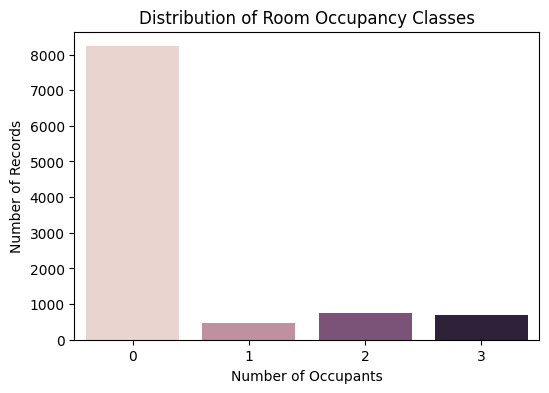

In [6]:
print("\nTarget Distribution:")
print(df["Room_Occupancy_Count"].value_counts().sort_index())
 
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="Room_Occupancy_Count",
    hue="Room_Occupancy_Count",
    legend=False
    )
plt.title("Distribution of Room Occupancy Classes")
plt.xlabel("Number of Occupants")
plt.ylabel("Number of Records")
plt.show()

### 4. Feature Engineering

In [7]:
# Convert Date and Time into datetime
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"]
)
 
df["Hour"] = df["DateTime"].dt.hour
df["Minute"] = df["DateTime"].dt.minute
df["DayOfWeek"] = df["DateTime"].dt.dayofweek
 
# Aggregate sensor readings
df["Avg_Temp"] = df[
    ["S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp"]
].mean(axis=1)
 
df["Avg_Light"] = df[
    ["S1_Light", "S2_Light", "S3_Light", "S4_Light"]
].mean(axis=1)
 
df["Avg_Sound"] = df[
    ["S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound"]
].mean(axis=1)
 
df["PIR_Total"] = df["S6_PIR"] + df["S7_PIR"]


### 5. Select Features and Target

In [9]:
feature_cols = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope",
    "S6_PIR", "S7_PIR",
    "Hour", "Minute", "DayOfWeek",
    "Avg_Temp", "Avg_Light", "Avg_Sound", "PIR_Total"
]
 
X = df[feature_cols]
y = df["Room_Occupancy_Count"]
 
print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Matrix Shape: (10129, 23)
Target Shape: (10129,)


### 6. Correlation Heatmap

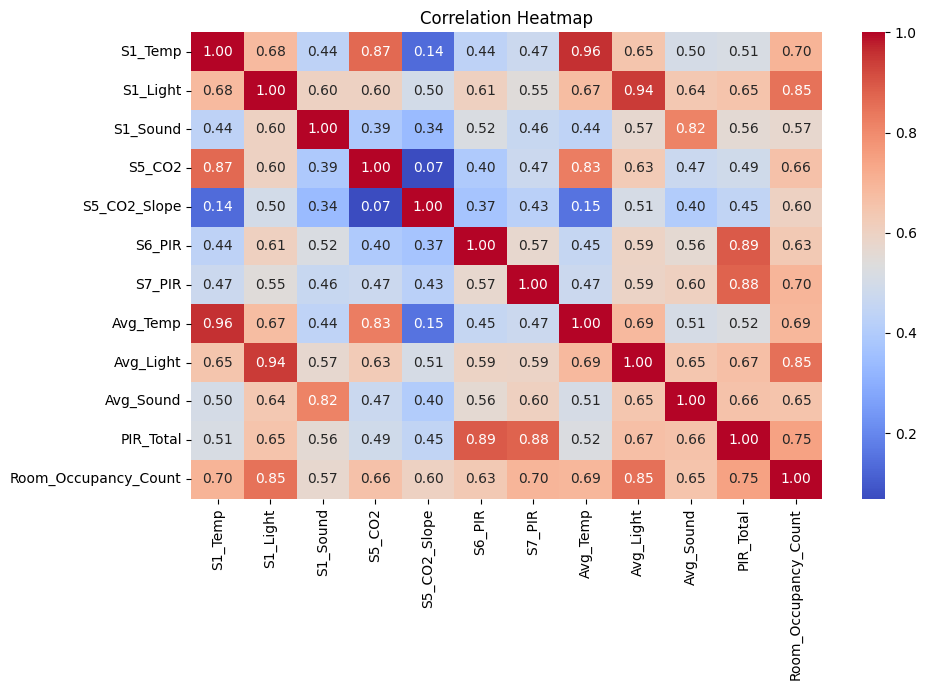

In [10]:
corr_cols = [
    "S1_Temp", "S1_Light", "S1_Sound",
    "S5_CO2", "S5_CO2_Slope",
    "S6_PIR", "S7_PIR",
    "Avg_Temp", "Avg_Light",
    "Avg_Sound", "PIR_Total",
    "Room_Occupancy_Count"
]
 
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 7. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
 
print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])



Training Samples: 8103
Testing Samples: 2026


### 8. Define Models

In [12]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
 
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
 
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

### 9. Train and Evaluate Models

In [13]:
results = []
 
for name, model in models.items():
 
    model.fit(X_train, y_train)
 
    y_pred = model.predict(X_test)
 
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
 
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])
 
    print("\n", "=" * 50)
    print(name)
    print("=" * 50)
 
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)
 
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )
 


Logistic Regression
Accuracy : 0.9945705824284304
Precision: 0.9947630676808614
Recall   : 0.9945705824284304
F1-Score : 0.9945443513926903

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1646
           1       1.00      1.00      1.00        92
           2       0.94      0.99      0.97       149
           3       0.99      0.93      0.96       139

    accuracy                           0.99      2026
   macro avg       0.98      0.98      0.98      2026
weighted avg       0.99      0.99      0.99      2026


KNN
Accuracy : 0.9940769990128332
Precision: 0.9943319792448836
Recall   : 0.9940769990128332
F1-Score : 0.9940989110167419

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1646
           1       0.99      0.99      0.99        92
           2       0.94      0.99      0.96       149
           3       0.99      0.94 

### 10. Model Comparison

In [14]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)
 
print("\nFinal Model Comparison:")
display(results_df)



Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.994571,0.994763,0.994571,0.994544
1,KNN,0.994077,0.994332,0.994077,0.994099
2,Random Forest,0.997532,0.997584,0.997532,0.997523


### 11. Confusion Matrix for Each Model

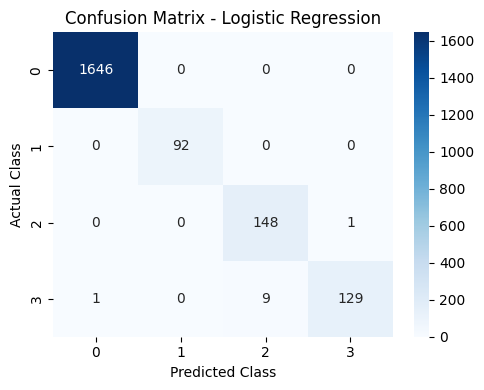

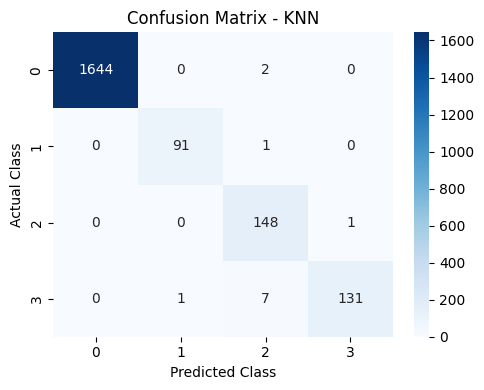

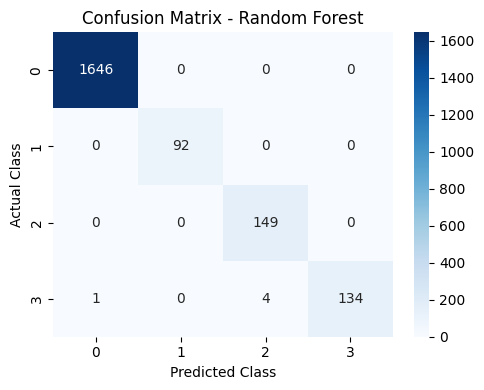

In [15]:
for name, model in models.items():
 
    y_pred = model.predict(X_test)
 
    cm = confusion_matrix(y_test, y_pred)
 
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
 
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

### 12. Model Performance Comparison

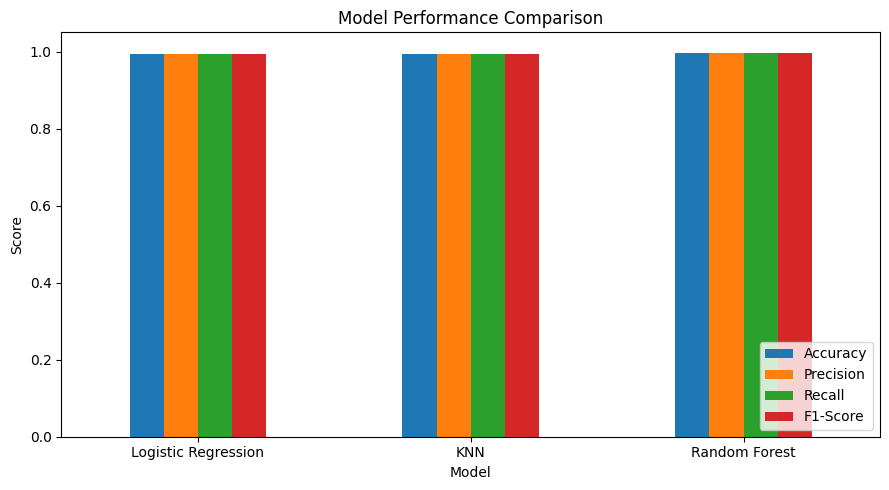

In [16]:
results_plot = results_df.set_index("Model")
 
results_plot[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(9, 5)
)
 
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 13. Random Forest Feature Importance

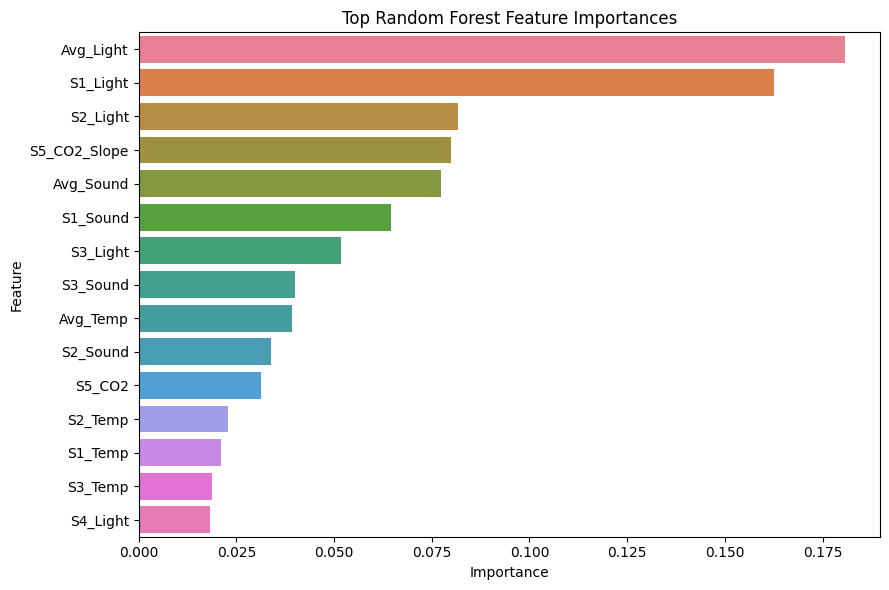


Top Features:


,Feature,Importance
20,Avg_Light,0.180659
4,S1_Light,0.162473
5,S2_Light,0.081635
13,S5_CO2_Slope,0.079951
21,Avg_Sound,0.077383
8,S1_Sound,0.064460
6,S3_Light,0.051774
10,S3_Sound,0.040109
19,Avg_Temp,0.039110
9,S2_Sound,0.033940


In [17]:
rf_model = models["Random Forest"]
 
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
})
 
importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(15)
 
plt.figure(figsize=(9, 6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False
)
 
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()
 
print("\nTop Features:")
display(importance)
